In [ ]:
# imports
import numpy as np
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    normalized_mutual_info_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [14]:
# Load the GreekLegalSum training split
ds = load_dataset("DominusTea/GreekLegalSum", split="train")
df = pd.DataFrame(ds[:])

In [15]:
# Parse 'case_tags' (comma-separated string) into a list
def parse_tags(x):
    if isinstance(x, str):
        # split on comma, strip whitespace, drop empty entries
        return [tag.strip() for tag in x.split(",") if tag.strip()]
    else:
        return []

In [16]:
df['case_tags_list'] = df['case_tags'].apply(parse_tags)

In [17]:
# Count frequencies of tags and categories
tag_counts = (
    df
    .explode('case_tags_list')['case_tags_list']
    .value_counts()
    .sort_values(ascending=False)
)

In [18]:
cat_counts = (
    df['case_category']
      .value_counts()           
      .sort_values(ascending=False)  
)

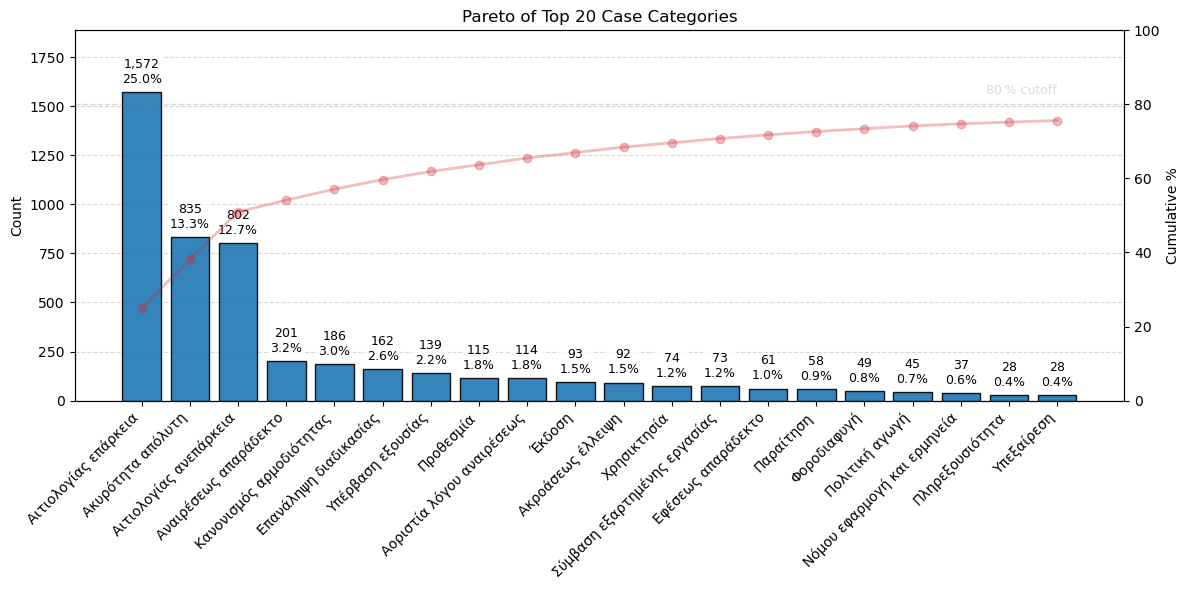

In [19]:
# --- Plot 1: Pareto of Top 20 Case Categories ---
# This plot answers: "Which case categories are most frequent, and how much
# of the corpus does the top-20 cover?"
cat_counts   = df['case_category'].value_counts().sort_values(ascending=False)
top20_cat    = cat_counts.head(20)
cumperc_cat  = top20_cat.cumsum() / cat_counts.sum() * 100

fig, ax1 = plt.subplots(figsize=(12, 6))

# 1) Bars (in front)
bars = ax1.bar(
    top20_cat.index, top20_cat.values,
    color="C0", alpha=0.9, zorder=5, edgecolor="black"
)
ax1.set_title("Pareto of Top 20 Case Categories")
ax1.set_ylabel("Count")
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

# 2) Annotate bars: count + percent
total_cat = cat_counts.sum()
max_cat   = top20_cat.max()
for bar, cnt in zip(bars, top20_cat.values):
    pct = cnt / total_cat * 100
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        cnt + max_cat*0.02,
        f"{cnt:,}\n{pct:.1f}%",
        ha="center", va="bottom",
        fontsize=9,
        zorder=6,
        bbox=dict(fc="white", ec="none", alpha=0.8, pad=1)
    )

# 3) Semi‑transparent cumulative‑% line (behind bars)
ax2 = ax1.twinx()
line, = ax2.plot(
    top20_cat.index, cumperc_cat,
    color="C3", marker="o", linewidth=2,
    alpha=0.3, zorder=3
)
ax2.set_ylabel("Cumulative %")
ax2.set_ylim(0, 100)

# 4) 80% cutoff in the same transparent style
ax2.axhline(80, color="gray", linestyle="--", linewidth=1, alpha=0.3, zorder=2)
ax2.text(
    len(top20_cat)-1, 82, "80 % cutoff",
    ha="right", va="bottom",
    color="gray", fontsize=9, alpha=0.3
)

ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.set_ylim(0, max_cat * 1.2)
plt.tight_layout()
plt.show()


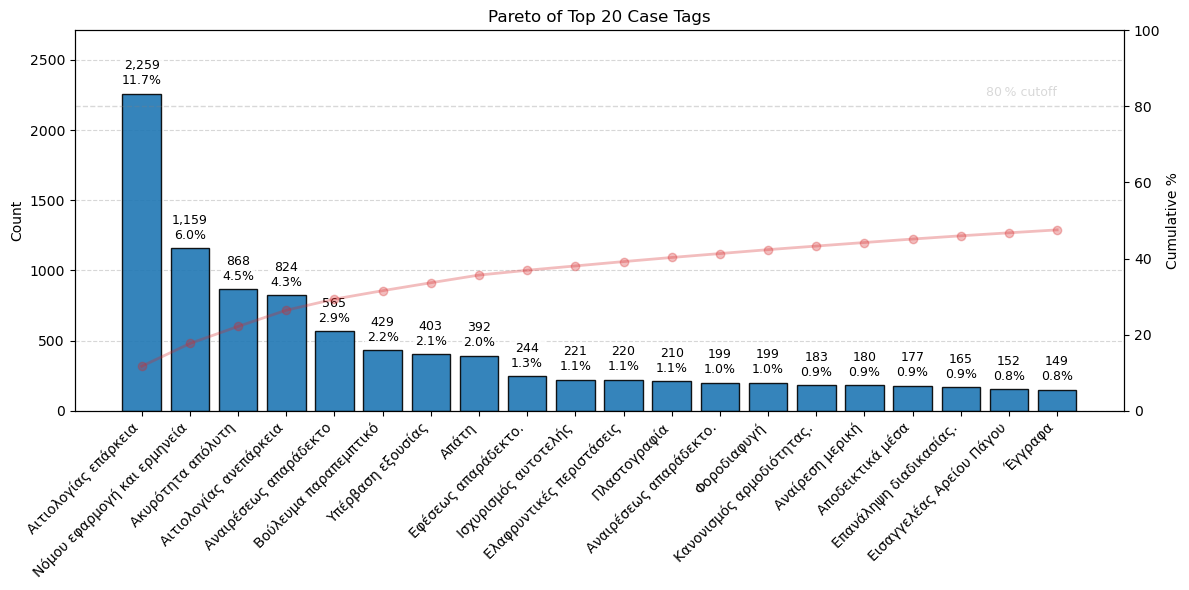

In [20]:
# --- Plot 2: Pareto of Top 20 Case Tags ---
# This plot answers: "Which individual case tags are most frequent, and what
# cumulative coverage do the top-20 tags achieve?"
tag_counts    = df.explode('case_tags_list')['case_tags_list'] \
                   .value_counts().sort_values(ascending=False)
top20_tag     = tag_counts.head(20)
cumperc_tag   = top20_tag.cumsum() / tag_counts.sum() * 100

fig, ax1 = plt.subplots(figsize=(12, 6))

# 1) Bars
bars = ax1.bar(
    top20_tag.index, top20_tag.values,
    color="C0", alpha=0.9, zorder=5, edgecolor="black"
)
ax1.set_title("Pareto of Top 20 Case Tags")
ax1.set_ylabel("Count")
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

# 2) Annotate bars
total_tag = tag_counts.sum()
max_tag   = top20_tag.max()
for bar, cnt in zip(bars, top20_tag.values):
    pct = cnt / total_tag * 100
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        cnt + max_tag*0.02,
        f"{cnt:,}\n{pct:.1f}%",
        ha="center", va="bottom",
        fontsize=9,
        zorder=6,
        bbox=dict(fc="white", ec="none", alpha=0.8, pad=1)
    )

# 3) Semi‑transparent cumulative‑% line
ax2 = ax1.twinx()
ax2.plot(
    top20_tag.index, cumperc_tag,
    color="C3", marker="o", linewidth=2,
    alpha=0.3, zorder=3
)
ax2.set_ylabel("Cumulative %")
ax2.set_ylim(0, 100)

# 4) 80% cutoff
ax2.axhline(80, color="gray", linestyle="--", linewidth=1, alpha=0.3, zorder=2)
ax2.text(
    len(top20_tag)-1, 82, "80 % cutoff",
    ha="right", va="bottom",
    color="gray", fontsize=9, alpha=0.3
)

ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.set_ylim(0, max_tag * 1.2)
plt.tight_layout()
plt.show()

In [26]:
# --- Data Quality Checks & Summary Statistics ---
# These printouts answer: "Are there missing values, and how many unique labels?"
print("Missing case_category:", df['case_category'].isna().sum())
print("Missing case_tags:",     df['case_tags'].isna().sum())

Missing case_category: 2097
Missing case_tags: 2097


In [27]:
print("Unique categories:", df['case_category'].nunique())
print("Unique tags:",       len(tag_counts))

Unique categories: 399
Unique tags: 997


In [28]:
# 1) Extract the two sets
categories = set(df['case_category'].dropna().unique())
tags       = set(df.explode('case_tags_list')['case_tags_list'].dropna().unique())

# 2) Compute intersections and differences
both     = categories & tags
only_cat = categories - tags
only_tag = tags - categories

print(f"Total distinct categories: {len(categories)}")
print(f"Total distinct tags      : {len(tags)}")
print(f"Overlap (in both)        : {len(both)}")
print(f"Categories not in tags   : {only_cat}")
print(f"Tags not in categories   : {len(only_tag)} items")


Total distinct categories: 399
Total distinct tags      : 997
Overlap (in both)        : 251
Categories not in tags   : {'Αγωγή αρνητική', 'Φυγόδικος', 'Εταιρία ανώνυμη', "Εφ' άπαξ επίδομα", 'Κρητικός Αστικός Κώδικας', 'Ανάκληση αναστολής ποινής', 'Άσκηση δεύτερης αίτησης αναίρεσης', 'Εικονικότητα σύμβασης', 'Καταγγελία σύμβασης εργασίας', 'Πληρεξουσιότητα ', 'Επίδομα πληροφορικής', 'Βούλευμα', 'Όπλων εμπορία', "Εφ' άπαξ αμοιβή", 'Εξαιρέσεως αίτηση', 'Επίδειξη εγγράφων', 'παραβιάσεις κανόνων του δικονομικού δικαίου', 'Διατάραξη ασφάλειας συγκοινωνιών', 'Σύσταση ιδιοκτησίας', 'Ανάκληση μη οριστικής απόφασης', 'Σύμβαση εργασίας άκυρη', 'Μεσιτεία', 'Πιλοτή (Pilotis)', 'Αποδοχής δήλωση', 'Υγειονομική νομοθεσία', 'Απόφαση παρεμπίπτουσα', 'Πράξη εφαρμογής πολεοδομικής μελέτης', 'Ακύρωση δικαιοπραξίας', 'Χρεοκοπία δόλια', 'Ισότητα παροχών', 'Πλειστηριασμός ', 'Προσύμφωνο', 'Κλήτευση προσθέτως παρεμβαίνοντα', 'Δικαστική διανομή', 'Παραπομπή στην Ολομέλεια του Αρείου Πάγου', 'Σύμβαση πωλήσεως',

In [ ]:
texts   = ds["summary"]                     
raw_cat = [c if isinstance(c, str) else "NO_CAT" for c in ds["case_category"]]
raw_tag = [t[0] if isinstance(t, list) and t else "NO_TAG" for t in ds["case_tags"]]
cat_enc = LabelEncoder().fit(raw_cat)
tag_enc = LabelEncoder().fit(raw_tag)
y_cat   = cat_enc.transform(raw_cat)
y_tag   = tag_enc.transform(raw_tag)


In [30]:
docs = [txt.lower().split() for txt in texts]

In [ ]:
# 1) helper to parse all tags
def parse_tags(x):
    if isinstance(x, str):
        return [t.strip() for t in x.split(",") if t.strip()]
    else:
        return []

raw_tags_list = [parse_tags(t) for t in ds["case_tags"]]

In [32]:
# 2) Build context‐enhanced texts
texts_with_context = []
for i, (cat, tags, summ) in enumerate(zip(raw_cat, raw_tags_list, texts)):
    tag_str = ", ".join(tags) if tags else "NO_TAG"
    texts_with_context.append(
        f"[ΚΑΤΗΓΟΡΙΑ: {cat}] [ΕΤΙΚΕΤΕΣ: {tag_str}] {summ or ''}"
    )


In [33]:
# 3) Encode the true labels for later evaluation
y_cat = LabelEncoder().fit_transform(raw_cat)
y_tag = LabelEncoder().fit_transform(
    [tags[0] if tags else "NO_TAG" for tags in raw_tags_list]
)

In [37]:
# 4) TF–IDF vectorization over the augmented texts
tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1,3),
    max_df=0.80,
    min_df=10,
    max_features=15000
)
X_tfidf = tfidf.fit_transform(texts_with_context)

# LSA (Truncated SVD) to reduce to 100 dimensions
svd = TruncatedSVD(n_components=100, random_state=42)
Z   = svd.fit_transform(X_tfidf)

# Normalize for cosine similarity clustering
Xp = normalize(Z, norm="l2")

# Macro‐silhouette helper
def silhouette_macro(X, labels):
    s = silhouette_samples(X, labels, metric='cosine')
    return np.mean([s[labels==k].mean() for k in np.unique(labels) if np.any(labels==k)])

In [40]:
# 5) Sweep over K and report metrics
print(f"{'K':>2}  {'sil_micro':>10}  {'sil_macro':>10}  {'NMI_cat':>8}  {'NMI_tag':>8}")
for K in range(2, 80):
    km  = KMeans(n_clusters=K, n_init=20, random_state=42)
    lbl = km.fit_predict(Xp)
    sil_u = silhouette_score(Xp, lbl, metric='cosine')
    sil_M = silhouette_macro(Xp, lbl)
    nmi_c = normalized_mutual_info_score(y_cat, lbl)
    nmi_t = normalized_mutual_info_score(y_tag, lbl)
    print(f"{K:2d}  {sil_u:10.4f}  {sil_M:10.4f}  {nmi_c:8.4f}  {nmi_t:8.4f}")


 K   sil_micro   sil_macro   NMI_cat   NMI_tag
 2      0.0762      0.0770    0.2410    0.2587
 3      0.0767      0.0737    0.2439    0.2547
 4      0.0923      0.1172    0.3305    0.3389
 5      0.1096      0.2368    0.3652    0.3744
 6      0.1130      0.1519    0.4947    0.4540
 7      0.1312      0.2316    0.5177    0.4785
 8      0.1344      0.2250    0.5248    0.4898
 9      0.1457      0.2745    0.5212    0.4883
10      0.1590      0.3143    0.5399    0.5060
11      0.1629      0.2998    0.5324    0.5015
12      0.1615      0.2703    0.5399    0.5059
13      0.1740      0.3215    0.5491    0.4990
14      0.1624      0.3151    0.5466    0.4953
15      0.1769      0.3218    0.5533    0.5152
16      0.1771      0.2894    0.5248    0.4853
17      0.1850      0.2907    0.5300    0.5008
18      0.1956      0.3137    0.5572    0.5155
19      0.1863      0.2794    0.5601    0.5066
20      0.1964      0.3176    0.5596    0.5145
21      0.1993      0.2968    0.5326    0.5008
22      0.206

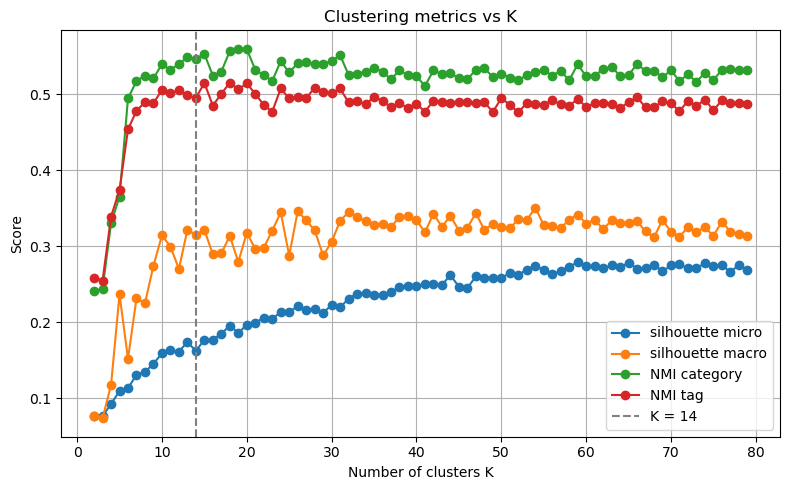

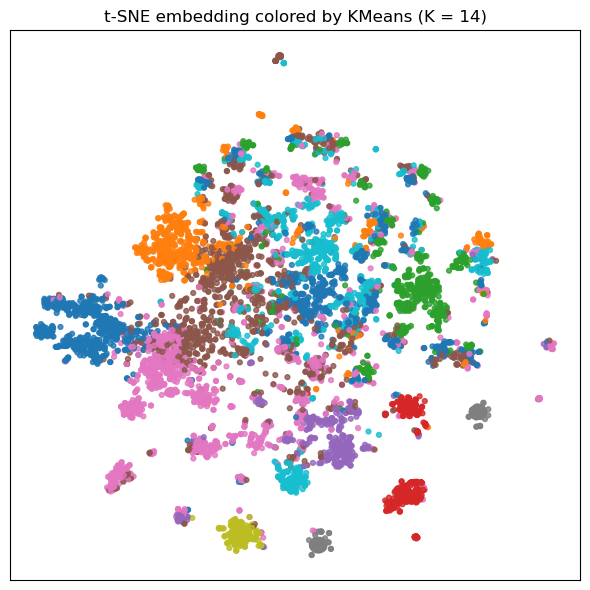

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, normalized_mutual_info_score
from sklearn.manifold import TSNE

# 1) K range
Ks = list(range(2, 80))

# 2) Lists for metrics
sil_micro_list = []
sil_macro_list = []
nmi_cat_list   = []
nmi_tag_list   = []

# 3) Compute metrics for each K
for K in Ks:
    km = KMeans(n_clusters=K, n_init=20, random_state=42)
    lbl = km.fit_predict(Xp)
    
    # micro silhouette
    sil_u = silhouette_score(Xp, lbl, metric='cosine')
    sil_micro_list.append(sil_u)
    
    # macro silhouette
    samp = silhouette_samples(Xp, lbl, metric='cosine')
    sil_M = np.mean([samp[lbl == k].mean() for k in np.unique(lbl)])
    sil_macro_list.append(sil_M)
    
    # NMI on categories and tags
    nmi_c = normalized_mutual_info_score(y_cat, lbl)
    nmi_t = normalized_mutual_info_score(y_tag, lbl)
    nmi_cat_list.append(nmi_c)
    nmi_tag_list.append(nmi_t)

# 4) Plot metrics vs K,for K=14
plt.figure(figsize=(8, 5))
plt.plot(Ks, sil_micro_list, marker='o', label='silhouette micro')
plt.plot(Ks, sil_macro_list, marker='o', label='silhouette macro')
plt.plot(Ks, nmi_cat_list,   marker='o', label='NMI category')
plt.plot(Ks, nmi_tag_list,   marker='o', label='NMI tag')
plt.axvline(14, color='gray', linestyle='--', label='K = 14')
plt.xlabel('Number of clusters K')
plt.ylabel('Score')
plt.title('Clustering metrics vs K')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 5) t-SNE visualization K = 14
Kbest = 14
km14 = KMeans(n_clusters=Kbest, n_init=20, random_state=42)
labels14 = km14.fit_predict(Xp)

tsne = TSNE(n_components=2, metric='cosine', random_state=42)
X2d = tsne.fit_transform(Xp)

plt.figure(figsize=(6, 6))
plt.scatter(X2d[:, 0], X2d[:, 1], c=labels14, cmap='tab10', s=12, alpha=0.8)
plt.title(f"t-SNE embedding colored by KMeans (K = {Kbest})")
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()

In [ ]:
raw_tags_list = [parse_tags(x) for x in ds["case_tags"]]

texts_with_context = [
    f"[ΚΑΤΗΓΟΡΙΑ: {cat}] [ΕΤΙΚΕΤΕΣ: {', '.join(tags)}] {ds['summary'][i] or ''}"
    for i, (cat, tags) in enumerate(zip(raw_cat, raw_tags_list))
]

for txt in texts_with_context[:3]:
    print(txt)

[ΚΑΤΗΓΟΡΙΑ: Ακυρότητα απόλυτη] [ΕΤΙΚΕΤΕΣ: Αιτιολογίας επάρκεια, Ακυρότητα απόλυτη, Απάτη, Νόμου εφαρμογή και ερμηνεία, Πλαστογραφία, Καταχραστές Δημοσίου.] Αίτηση αναίρεσης καταδικαστικής αποφάσεως για πλαστογραφία με χρήση και κακουργηματική απάτη κατ’ εξακολούθηση με τη συνδρομή του Ν. 1608/1950 και για ηθική αυτουργία με την επίκληση των λόγων: α) της ελλείψεως ειδικής και εμπεριστατωμένης αιτιολογίας, β) της εσφαλμένης ερμηνείας και εφαρμογής των ουσιαστικών ποινικών διατάξεων, γ) της απόλυτης ακυρότητας. Υπάρχει αιτιολογία, τόσο ως προς την ενοχή, όσο και για τον αυτοτελή ισχυρισμό του άρθρου 84 παρ. 2α του ΠΚ. Συρρέει η χρήση πλαστού εγγράφου με την απάτη κατ’ εξακολούθηση (ΑΠ 965/2006). Απορρίπτει αιτήσεις αναίρεσης.
[ΚΑΤΗΓΟΡΙΑ: Ποινή συνολική] [ΕΤΙΚΕΤΕΣ: Ποινή συνολική, Νόμου εφαρμογή και ερμηνεία, Εισαγγελέας Αρείου Πάγου.] Καθορισμός συνολικής ποινής (άρθρο 551 ΚΠΔ) με ποινές που προέρχονται από προηγούμενη συγχώνευση). Εσφαλμένη εφαρμογή ταυ νόμου. Αίτηση αναίρεσης από Εισαγ